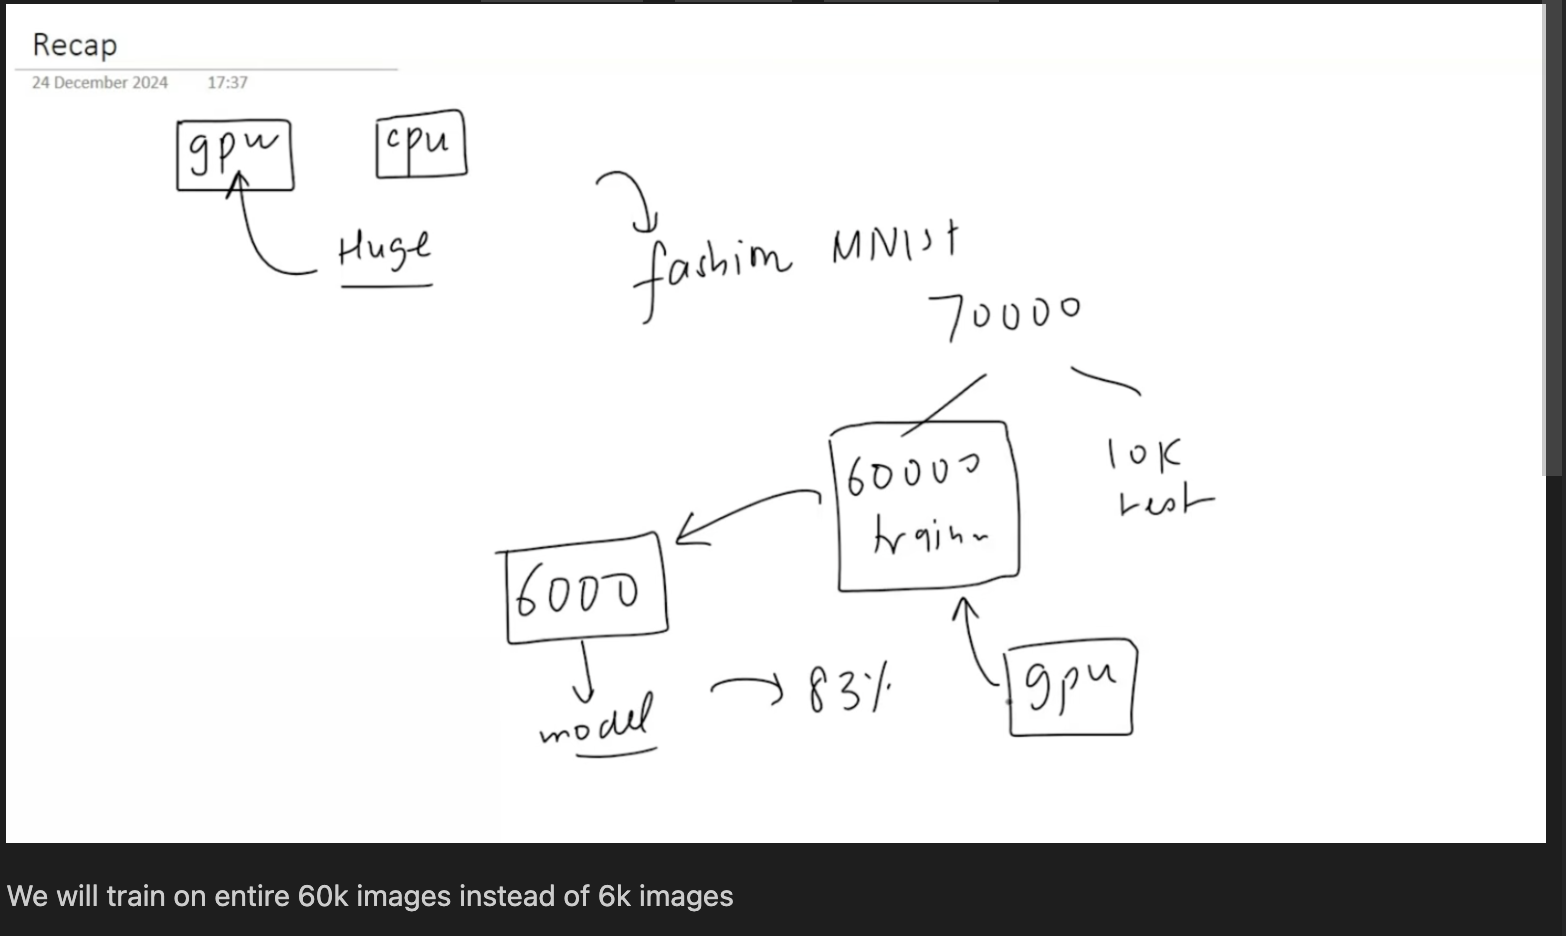

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt

In [2]:
## setting the seed for reproducibility
torch.manual_seed(42)

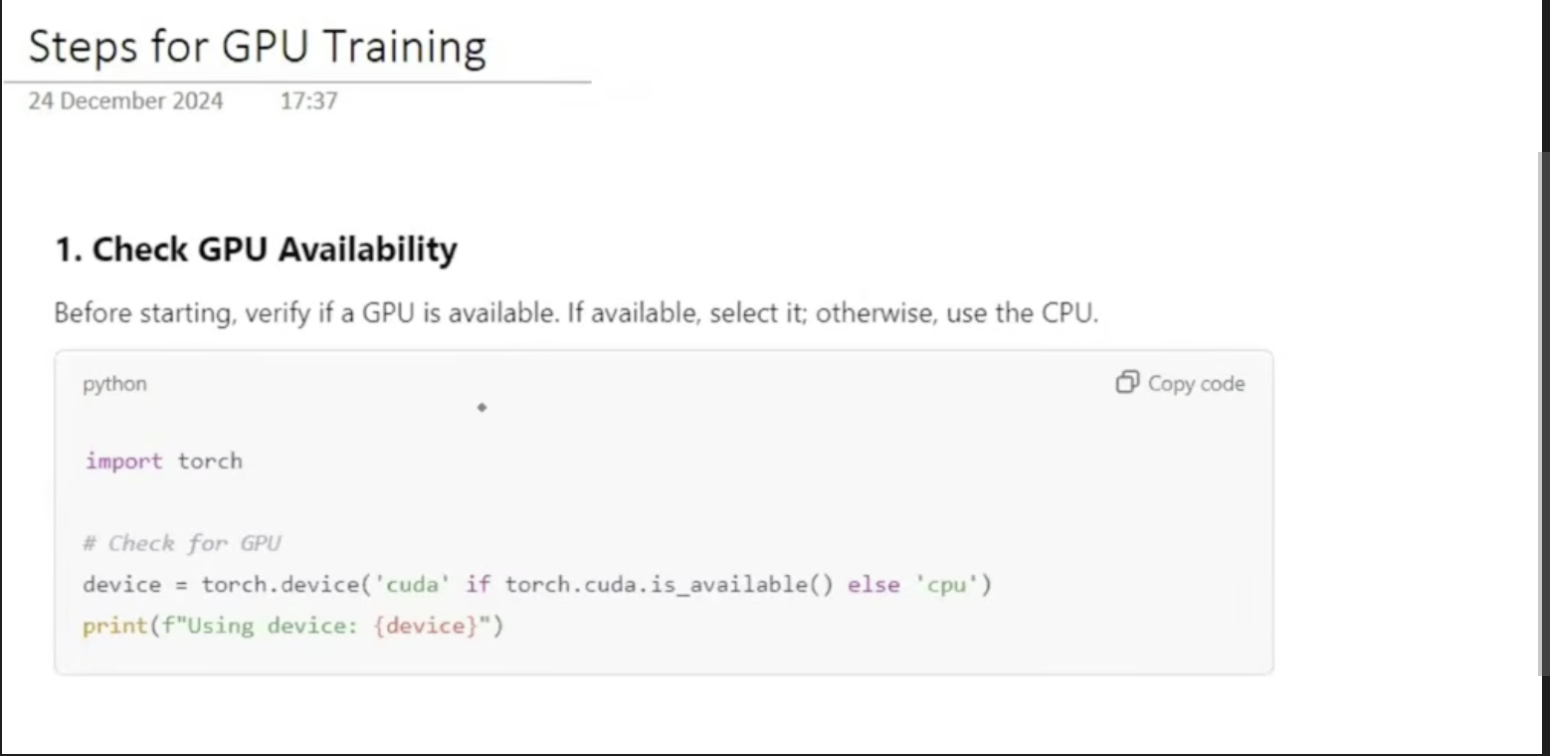

In [4]:
import torch

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device:{device}")

device:cuda


In [11]:
df=pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.shape

(60000, 785)

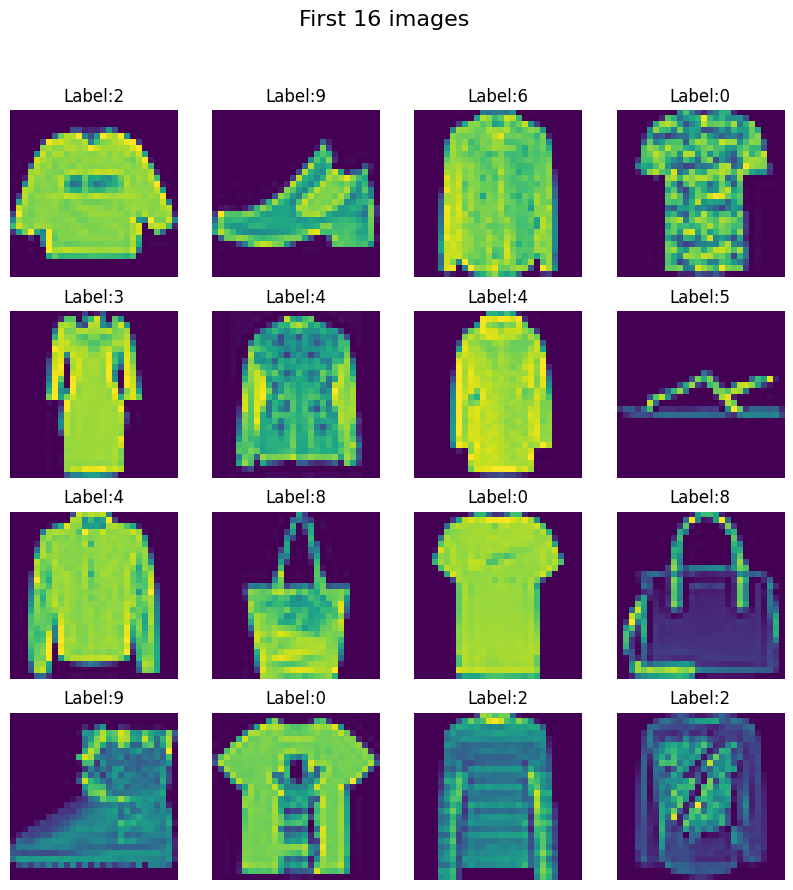

In [17]:
## create a 4X4 grid of images

fig,axes=plt.subplots(4,4,figsize=(10,10))
plt.suptitle('First 16 images',fontsize=16)

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.set_title(f"Label:{df.iloc[i,0]}")
  ax.axis('off')

plt.show()

In [19]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
X_train=X_train/255.0
X_test=X_test/255.0

In [30]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [31]:
train_loader=DataLoader(train_dataset,shuffle=True,batch_size=32)
test_loader=DataLoader(test_dataset,shuffle=False,batch_size=32)

In [32]:
len(train_loader)

1500

In [33]:
class ANN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),
    )

  def forward(self,X):
    out=self.model(X)
    return out

learning_rate=0.1
epochs=100



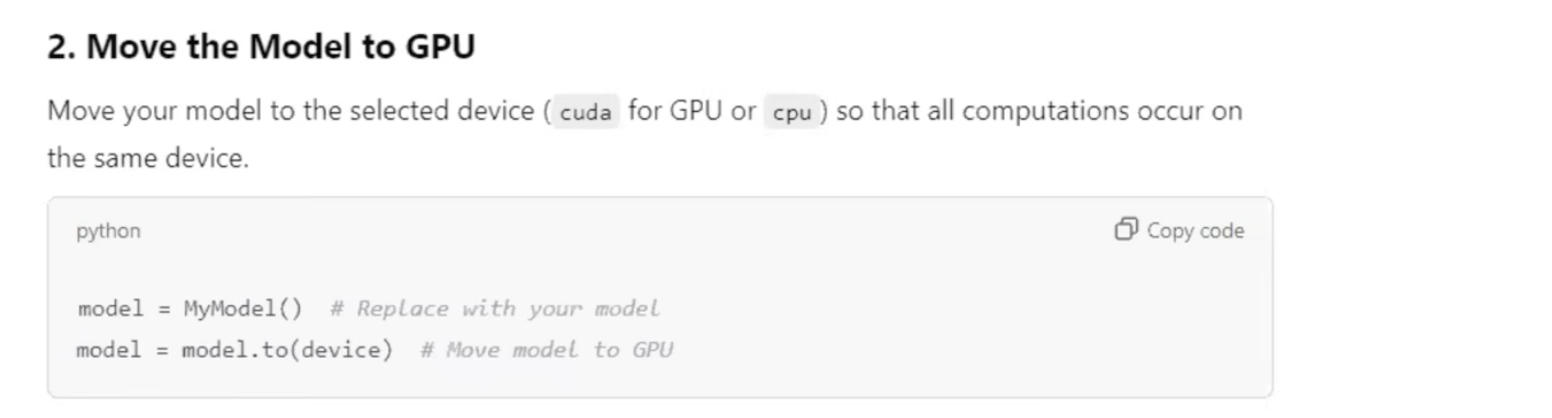

In [38]:
model=ANN(X_train.shape[1])
model=model.to(device)  ## moving the model to gpu

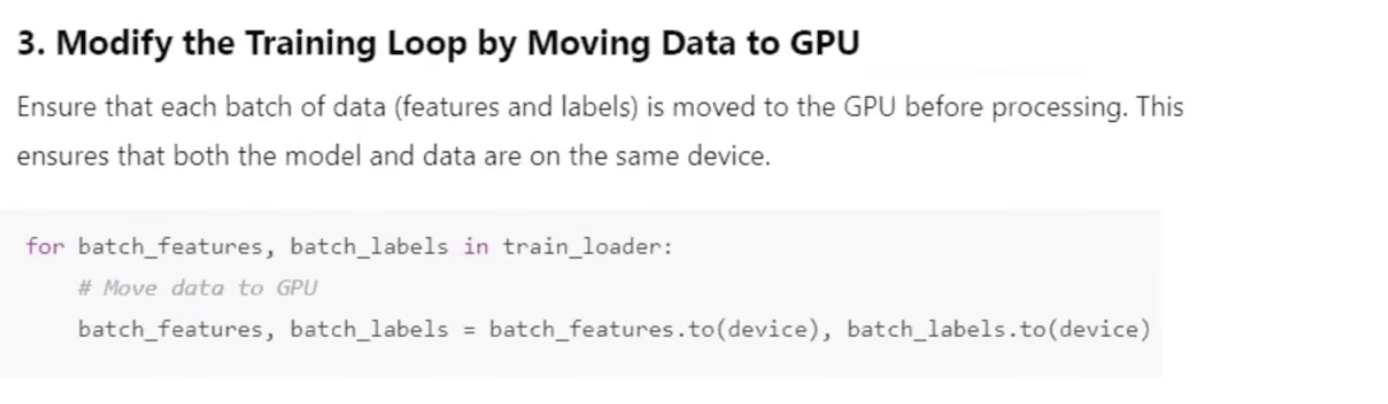

In [39]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
for epoch in range(epochs):
  total_epoch_loss=0

  for batch_features,batch_labels in train_loader:

    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    outputs=model(batch_features)
    loss=loss_fn(outputs,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss=total_epoch_loss+loss.item()
  avg_loss=total_epoch_loss/len(train_loader)
  print(f"Epoch:{epoch+1},Loss:{avg_loss}")

Epoch:1,Loss:0.6416670807202657
Epoch:2,Loss:0.43718449502686657
Epoch:3,Loss:0.3892857515960932
Epoch:4,Loss:0.3604276635348797
Epoch:5,Loss:0.3399443007707596
Epoch:6,Loss:0.3228084888483087
Epoch:7,Loss:0.30720346316695213
Epoch:8,Loss:0.2956286981056134
Epoch:9,Loss:0.2839984180132548
Epoch:10,Loss:0.27646761892860133
Epoch:11,Loss:0.26672555615628757
Epoch:12,Loss:0.25737843081975975
Epoch:13,Loss:0.2509864103794098
Epoch:14,Loss:0.24377940747390192
Epoch:15,Loss:0.2371868046435217
Epoch:16,Loss:0.22949264861891666
Epoch:17,Loss:0.22660902948180833
Epoch:18,Loss:0.21972302944088976
Epoch:19,Loss:0.21433711064172287
Epoch:20,Loss:0.208540784334143
Epoch:21,Loss:0.20497954759622614
Epoch:22,Loss:0.2030737263634801
Epoch:23,Loss:0.19710470984876155
Epoch:24,Loss:0.19298759193904697
Epoch:25,Loss:0.1913997886997337
Epoch:26,Loss:0.1829973910227418
Epoch:27,Loss:0.17956608230620622
Epoch:28,Loss:0.17550192871379355
Epoch:29,Loss:0.1742233672691509
Epoch:30,Loss:0.17088551535395285
Epoc

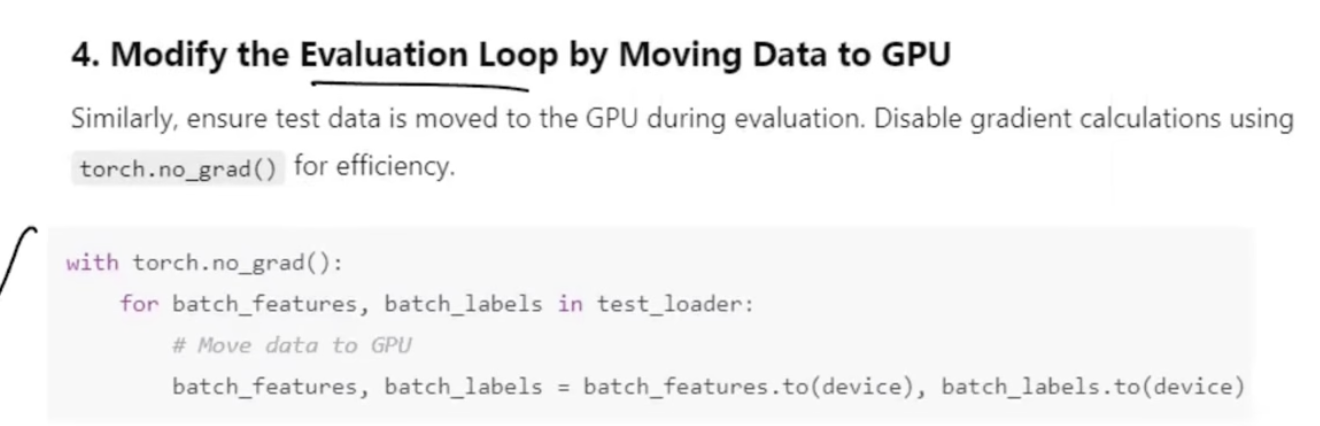

In [40]:
model.eval()
total=0
correct=0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    outputs=model(batch_features)
    _,predicted=torch.max(outputs,axis=1) ## we get the indices
    total=total+batch_labels.shape[0]
    correct=correct+(predicted==batch_labels).sum().item()
print(correct/total)

0.8888333333333334


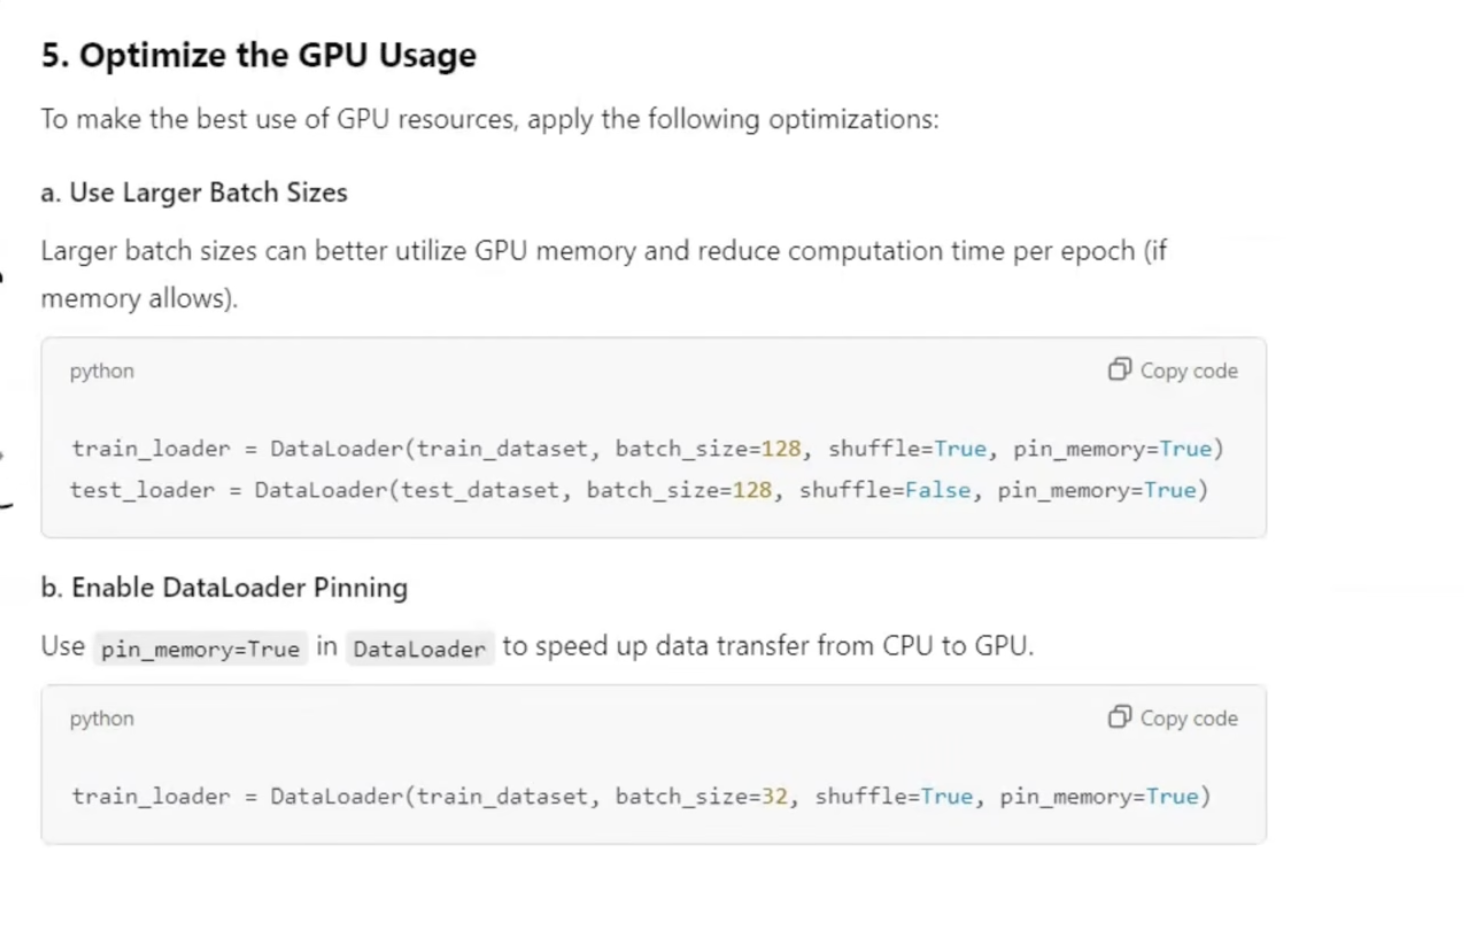

Concept of OS


Two memories are there : page/pager memory and ping memory


data resides in pager memory... it loads from pager to ping memory and then from ping to GPU

if we directly load data in ping memory then it saves overhead